<class 'pandas.core.frame.DataFrame'>
Index: 2180 entries, 45 to 2337
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           2180 non-null   object 
 1   year             2180 non-null   int64  
 2   poverty_percent  2180 non-null   float64
 3   region_standard  2180 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 85.2+ KB
None

Missing values by column:
 region             0
year               0
poverty_percent    0
region_standard    0
dtype: int64

Number of unique regions: 85
Number of unique years: 26

Poverty percentage statistics:
 count    2180.000000
mean       21.468119
std        12.838582
min         0.000000
25%        13.200000
50%        17.900000
75%        26.425000
max        98.400000
Name: poverty_percent, dtype: float64

Number of duplicate rows: 0

Number of outliers: 124

Top-5 observations:
            region_standard  year  poverty_percent
1051  Р

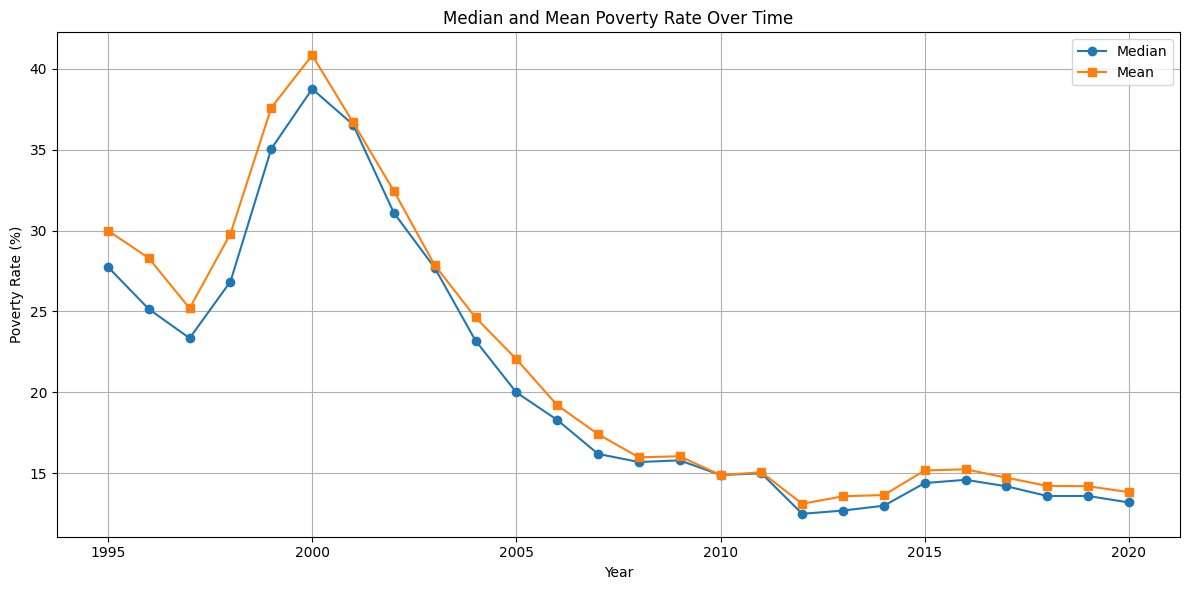

<Figure size 1600x600 with 0 Axes>

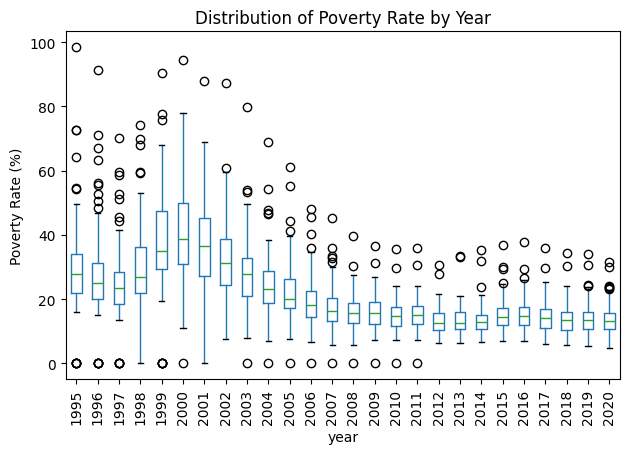

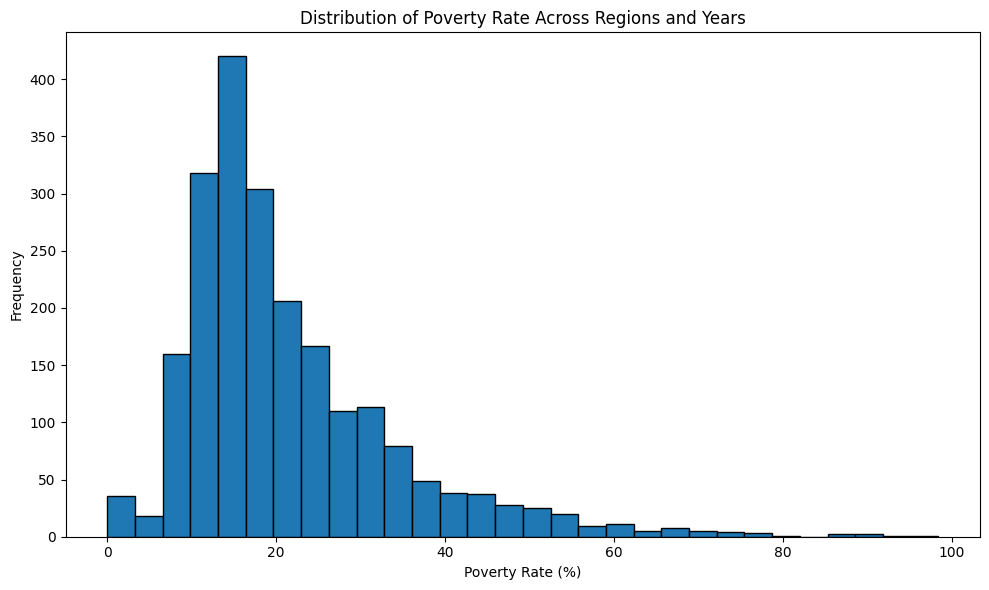

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/poverty_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()]

# 3. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 4. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 5. Summary statistics of poverty percentage
print("\nPoverty percentage statistics:\n", df["poverty_percent"].describe())

# 6. Check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

# 7. Detect outliers using IQR
Q1 = df["poverty_percent"].quantile(0.25)
Q3 = df["poverty_percent"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["poverty_percent"] < lower_bound) | (df["poverty_percent"] > upper_bound)]
print("\nNumber of outliers:", outliers.shape[0])

# 8. Top-5 highest poverty values
top5 = df.sort_values(by="poverty_percent", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "poverty_percent"]])

# 9. Median and mean trends over time
median_poverty = df.groupby("year")["poverty_percent"].median()
mean_poverty = df.groupby("year")["poverty_percent"].mean()

plt.figure(figsize=(12,6))
plt.plot(median_poverty.index, median_poverty.values, marker="o", label="Median")
plt.plot(mean_poverty.index, mean_poverty.values, marker="s", label="Mean")
plt.title("Median and Mean Poverty Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Poverty Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Boxplot by year
plt.figure(figsize=(16,6))
df.boxplot(column="poverty_percent", by="year", grid=False, rot=90)
plt.title("Distribution of Poverty Rate by Year")
plt.suptitle("")
plt.ylabel("Poverty Rate (%)")
plt.tight_layout()
plt.show()

# 11. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["poverty_percent"], bins=30, edgecolor="black")
plt.title("Distribution of Poverty Rate Across Regions and Years")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `poverty_standardized.csv` (filtered by `region_standard`)

## Data Description
- The dataset contains 2,180 observations across 85 regions.
- Time coverage: 1995–2021.
- Key variable: percentage of population living below the subsistence minimum.

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `poverty_percent`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values were detected.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~21.5%  
- Median: ~17.9%  
- Minimum: 0%  
- Maximum: 98.4%  
- 75% of observations are below ~26.4%  

This indicates a right-skewed distribution with a small number of regions experiencing extremely high poverty levels.

---

## Outliers
- 124 observations were identified as outliers using the IQR method.  
- Most extreme values correspond to the Republic of Ingushetia in the 1990s.  

These values are retained, as they reflect real historical conditions rather than data errors.

---

## Top-5 Highest Poverty Observations
All top values correspond to the Republic of Ingushetia:

1. 98.4%  
2. 94.3%  
3. 91.4%  
4. 90.5%  
5. 88.0%  

This highlights significant regional inequality in the earlier years of the dataset.

---

## Trends
- A clear downward trend in poverty is observed from the mid-1990s onward.  
- Both mean and median values decrease over time, indicating overall improvement.  
- However, the presence of extreme values suggests persistent regional disparities.

---

## Conclusion
The dataset is clean, consistent, and suitable for further analysis.

The observed variation in poverty levels across regions and over time suggests that regional socio-economic differences are substantial. This supports the use of clustering methods to identify groups of regions with similar characteristics in the next stage of the analysis.

In [2]:
df.to_csv("../../data/clean/poverty_AfterEDA.csv", index=False)